# Texas / Permian flaring — exploratory data analysis

Five figures on the Texas side of the Permian basin, from a single site x month panel
joining RRC lease production to VIIRS Nightfire detections.

1. Satellite radiant heat vs operator-reported vented/flared gas, over time
2. The same two quantities as a scatter, colored by year
3. Flared fraction of total gas
4. Oil production vs satellite radiant heat
5. Gas-to-oil ratio

**Input:** one merged CSV, site x month, containing the RRC production columns, the VIIRS
aggregates (`rh_sum`), and the outer-join indicator `_merge`.

**Radiant heat** throughout is `rh_sum` — the top-level radiant heat total. No cloud-mask
breakdown is used anywhere in this notebook, so the red line means the same thing on every figure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ---- input ----
PANEL_CSV = Path("../data/processed/merging/site_month_viirs_with_cloud_mask_joined_final.csv")

# ---- analysis choices (all figures respect these) ----
RH_COL             = "rh_sum"        # radiant heat. one definition, used everywhere.
SCRUB_SNPP_OUTAGE  = True            # null Aug-2022: SNPP was down, clear looks ~4% of normal
OUTAGE_MONTH       = pd.Timestamp("2022-08-01")

# ---- figure output ----
FIG_DIR   = Path("../results/eda_merged/")
FIG_DIR.mkdir(exist_ok=True)
SAVE_FIGS = True
SAVE_DPI  = 150

def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=SAVE_DPI, bbox_inches="tight")

def for_display(s):
    """Time-interpolate a NaN-carrying series so line plots don't show a hole.
    DISPLAY ONLY — never feed the result of this into a test or a model."""
    return s.interpolate(method="time")

---
## 1. Load

The panel is an outer join, so a site-month can be production-only (`left_only`), VIIRS-only
(`right_only`), or matched (`both`).

**Population.** Figures 1-3 compare a satellite quantity against a reported quantity *for the same
sites*, so they use matched rows only — otherwise a divergence between the two lines could just be
a population difference. Figures 4-5 aggregate each series over whatever rows carry it (pandas
`sum` skips NaN), so they use the full panel.

In [2]:
df = pd.read_csv(PANEL_CSV)

# canonical month-start timestamp. `year_month` is a YYYY-MM string; any `month` column in the
# file is an integer month number, not a date, so build the timestamp explicitly.
df["month_ts"] = pd.to_datetime(df["year_month"].astype(str) + "-01")

required = [RH_COL, "total_vented_flared_mcf", "oil_sold_total_bbl", "_merge", "year_month"]
missing  = [c for c in required if c not in df.columns]
assert not missing, f"panel is missing required columns: {missing}"

mm = df[df["_merge"] == "both"].copy()   # matched sites: production AND VIIRS present

print(df["_merge"].value_counts().to_string())
print(f"coverage: {df['month_ts'].min().date()} -> {df['month_ts'].max().date()}   rows: {len(df):,}")

_merge
both          209603
right_only     92953
left_only      18774
coverage: 2011-02-01 -> 2026-07-01   rows: 321,330


---
## 2. Monthly aggregates

Everything the figures need is built here, so the figure cells below are pure plotting.

- `comp` — matched sites: monthly radiant heat vs monthly reported vented/flared gas.
- `D` — matched sites: `flared / (captured + flared)`. Bounded in [0, 1] and tied directly to the 98%-capture rule.
- `panel` — full panel: monthly oil, monthly radiant heat, and the gas-to-oil ratio.

August 2022 is nulled in every radiant-heat series (SNPP outage — the drop is the satellite, not
the flaring). Line plots interpolate across it for display; the scatter simply drops it.

In [3]:
# ---- Figures 1 & 2: matched sites, satellite vs reported ----
gm = mm.groupby("month_ts")
comp = pd.DataFrame({
    "viirs_rh":     gm[RH_COL].sum(),
    "reported_mcf": gm["total_vented_flared_mcf"].sum(),
})

# ---- Figure 3: flared fraction of total gas, matched sites ----
CAPTURE_COLS = [
    "csgd_field_ops_fuel_mcf", "csgd_transmission_mcf", "csgd_processing_plant_mcf",
    "csgd_gas_lift_mcf", "csgd_repressure_mcf", "csgd_carbon_black_mcf",
    "csgd_underground_storage_mcf", "csgd_no_disp_code_mcf",
]
mm["captured_gas_mcf"] = mm[CAPTURE_COLS].sum(axis=1)
mm["total_gas_mcf"]    = mm["captured_gas_mcf"] + mm["total_vented_flared_mcf"]

gm = mm.groupby("month_ts")
D = pd.DataFrame({
    "flared":    gm["total_vented_flared_mcf"].sum(),
    "total_gas": gm["total_gas_mcf"].sum(),
})
D["flared_frac"] = D["flared"] / D["total_gas"]

# ---- Figures 4 & 5: full panel ----
GAS_COLS = [c for c in df.columns if "csgd" in c]   # all casinghead-gas dispositions
g = df.groupby("month_ts")
panel = pd.DataFrame({
    "rh":       g[RH_COL].sum(min_count=1),
    "oil_bbl":  g["oil_sold_total_bbl"].sum(min_count=1),
    "gas_mcf":  g[GAS_COLS].sum(min_count=1).sum(axis=1),
})
panel["gas_oil_ratio"] = panel["gas_mcf"] / panel["oil_bbl"].replace(0, np.nan)

# ---- SNPP outage: null the corrupted month in every radiant-heat series ----
if SCRUB_SNPP_OUTAGE:
    for frame, col in [(comp, "viirs_rh"), (panel, "rh")]:
        if OUTAGE_MONTH in frame.index:
            frame.loc[OUTAGE_MONTH, col] = np.nan

comp  = comp.sort_index()
D     = D.sort_index()
panel = panel.sort_index()

---
# Figures

## Figure 1 — Satellite radiant heat vs operator-reported vented/flared

Both series are the same matched sites under the same monthly aggregation, so any divergence
between them is signal, not population drift. The satellite series is exogenous to self-reporting:
operators report flaring to the regulator policing them; VIIRS does not.

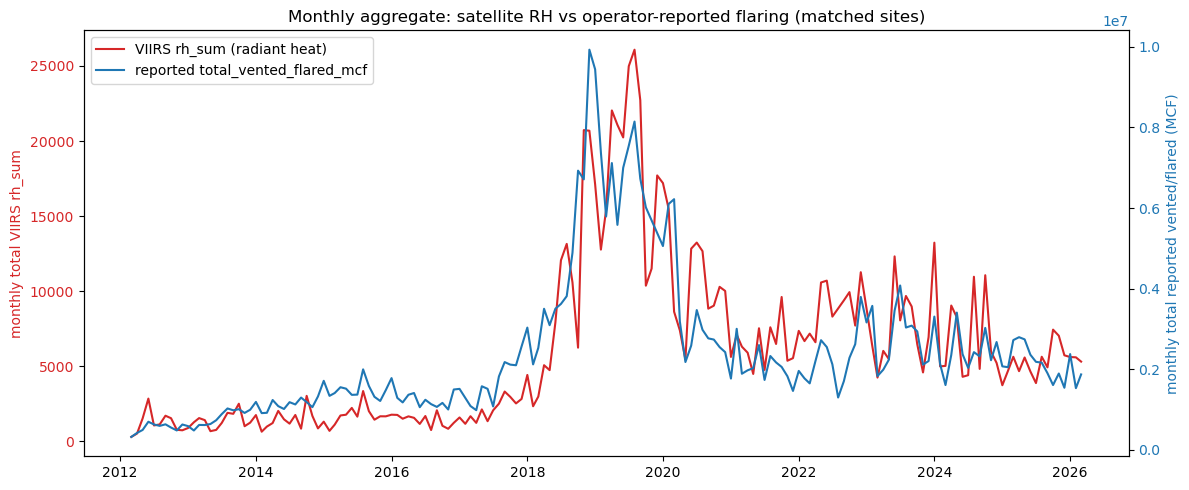

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 5))
l1, = ax1.plot(comp.index, for_display(comp["viirs_rh"]), color="tab:red", lw=1.5,
               label="VIIRS rh_sum (radiant heat)")
ax1.set_ylabel("monthly total VIIRS rh_sum", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
l2, = ax2.plot(comp.index, comp["reported_mcf"], color="tab:blue", lw=1.5,
               label="reported total_vented_flared_mcf")
ax2.set_ylabel("monthly total reported vented/flared (MCF)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("Monthly aggregate: satellite RH vs operator-reported flaring (matched sites)")
ax1.legend(handles=[l1, l2], loc="upper left")
plt.tight_layout()
save(fig, "fig1_rh_vs_reported_timeseries")
plt.show()

## Figure 2 — The same two series, as a scatter

Same `comp` frame as Figure 1, restricted to months where both series are strictly positive.
Points are colored by year, which is what makes the plot worth showing: if the relationship between
satellite and reported flaring were stable, the colors would be scrambled along the fit line rather
than sorted around it. The OLS line and R^2 are descriptive only.

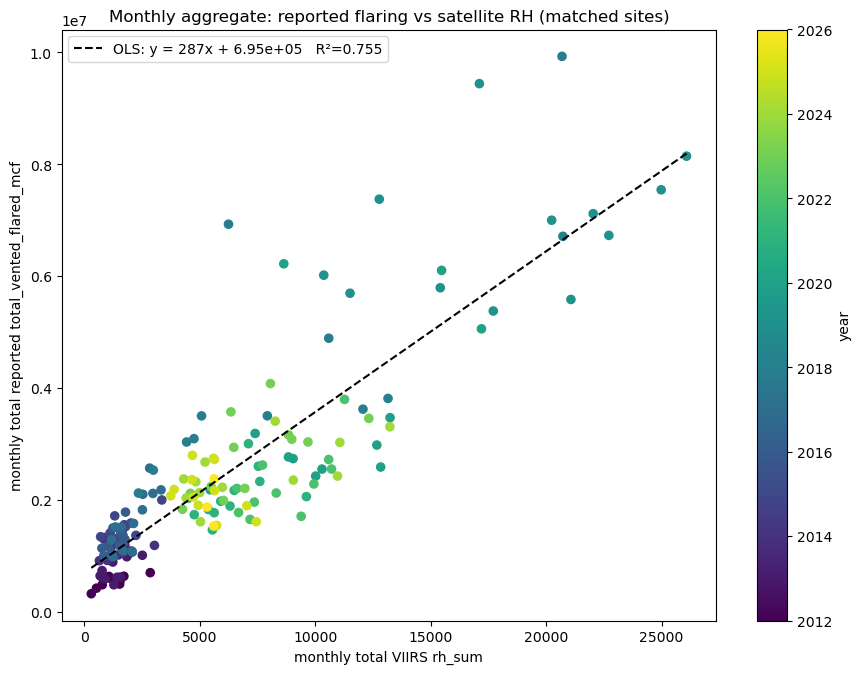

In [5]:
d = comp[(comp["viirs_rh"] > 0) & (comp["reported_mcf"] > 0)].copy()
d["year"] = d.index.year

x = d["viirs_rh"].values
y = d["reported_mcf"].values

slope, intercept = np.polyfit(x, y, 1)
yhat   = slope * x + intercept
r2     = 1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(x, y, c=d["year"], s=35, cmap="viridis")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, "k--", lw=1.5,
        label=f"OLS: y = {slope:.3g}x + {intercept:.3g}   R\u00b2={r2:.3f}")
ax.set_xlabel("monthly total VIIRS rh_sum")
ax.set_ylabel("monthly total reported total_vented_flared_mcf")
ax.set_title("Monthly aggregate: reported flaring vs satellite RH (matched sites)")
fig.colorbar(sc, ax=ax, label="year")
ax.legend()
plt.tight_layout()
save(fig, "fig2_rh_vs_reported_scatter")
plt.show()

## Figure 3 — Texas flared fraction of total gas

`flared / (captured + flared)` on matched sites — the bounded [0, 1] estimand tied directly to the
98%-capture rule.

The two sets of reference lines are the falsification design in one picture. Green is New Mexico's
rule date: Texas is the control, so nothing should happen there. Blue dotted lines are Texas
pipeline in-service dates: the confound the control *should* respond to.

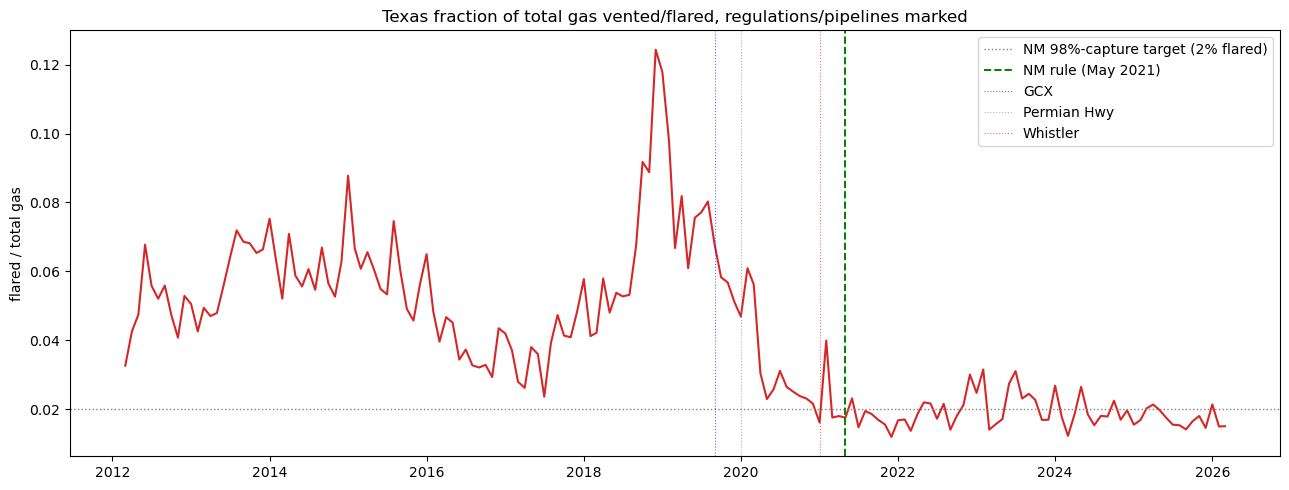

flared fraction: start 0.050 -> end 0.017


In [14]:
TX_PIPELINES = [("2019-09", "GCX", 'blue'), ("2020-01", "Permian Hwy", 'grey'), ("2021-01", "Whistler", 'red')]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(D.index, D["flared_frac"], color="tab:red", lw=1.5)
ax.axhline(0.02, color="gray", ls=":", lw=1, label="NM 98%-capture target (2% flared)")
ax.axvline(pd.Timestamp("2021-05-01"), color="green", ls="--", lw=1.4, label="NM rule (May 2021)")
for dt, lbl, clr in TX_PIPELINES:
    ax.axvline(pd.Timestamp(dt), ls=":", lw=0.8, alpha=0.6, label = lbl, color = clr)
ax.set_title("Texas fraction of total gas vented/flared, regulations/pipelines marked")
ax.set_ylabel("flared / total gas")
ax.legend()
plt.tight_layout()
save(fig, "fig3_flared_fraction")
plt.show()

print(f"flared fraction: start {D['flared_frac'].iloc[:6].mean():.3f}"
      f" -> end {D['flared_frac'].iloc[-6:].mean():.3f}")

## Figure 4 — Oil production vs satellite radiant heat

The decoupling in one picture: production climbs and radiant heat does not follow. The two y-axes
are independently scaled, so this shows divergence in *shape*, not in magnitude.

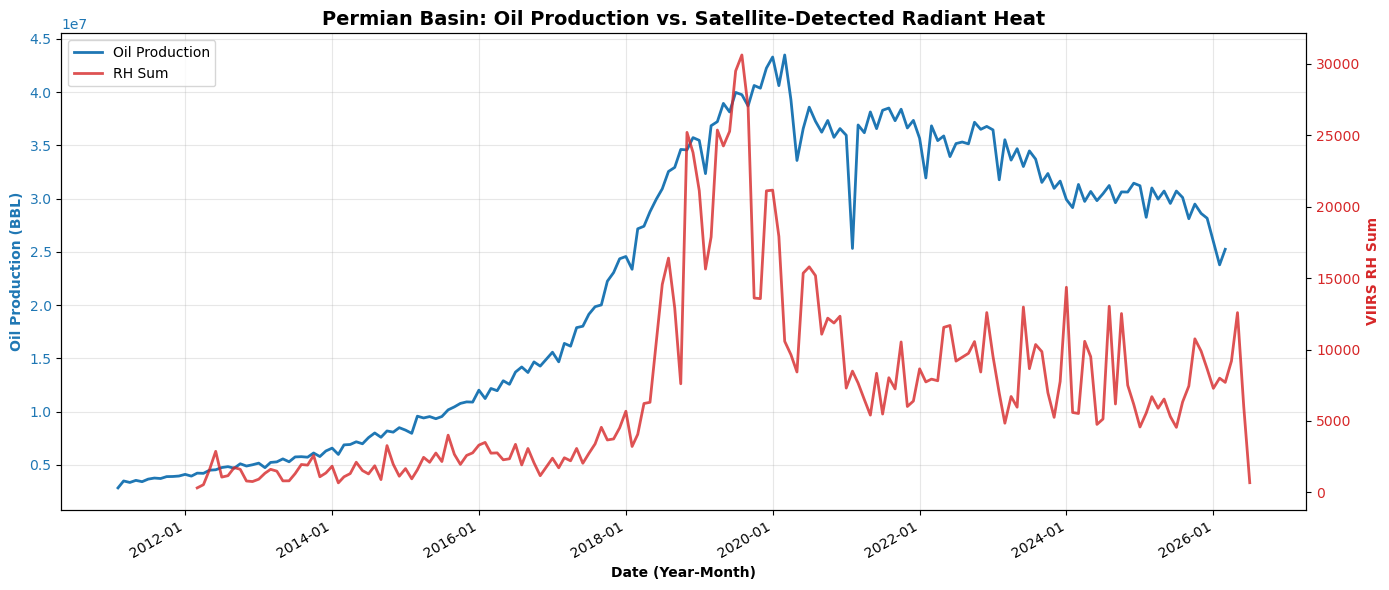

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 6))

c1 = "tab:blue"
ax1.set_xlabel("Date (Year-Month)", fontweight="bold")
ax1.set_ylabel("Oil Production (BBL)", color=c1, fontweight="bold")
line1 = ax1.plot(panel.index, panel["oil_bbl"], color=c1, linewidth=2, label="Oil Production")
ax1.tick_params(axis="y", labelcolor=c1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
c2 = "tab:red"
ax2.set_ylabel("VIIRS RH Sum", color=c2, fontweight="bold")
line2 = ax2.plot(panel.index, for_display(panel["rh"]), color=c2, linewidth=2, alpha=0.8,
                 label="RH Sum")
ax2.tick_params(axis="y", labelcolor=c2)

lines = line1 + line2
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left")

plt.title("Permian Basin: Oil Production vs. Satellite-Detected Radiant Heat",
          fontsize=14, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
save(fig, "fig4_oil_vs_rh")
plt.show()

## Figure 5 — Gas-to-oil ratio

Total casinghead gas per barrel of oil sold. This is the diagnostic behind the decision *not* to
reconstruct production from VIIRS: the GOR wanders, so any flaring-to-production conversion that
assumes a stable ratio inherits that wander as bias.

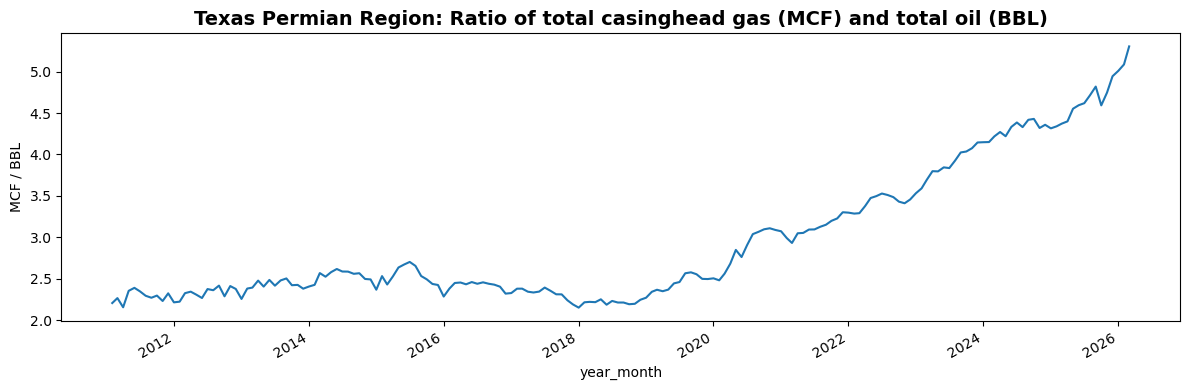

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(panel.index, panel["gas_oil_ratio"], color="C0")
ax.set_title("Texas Permian Region: Ratio of total casinghead gas (MCF) and total oil (BBL)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("year_month")
ax.set_ylabel("MCF / BBL")
fig.autofmt_xdate()
plt.tight_layout()
save(fig, "fig5_gas_oil_ratio")
plt.show()

---
## Notes on what these figures do and don't control for

1. **`.sum()` treats NaN as skipped, and an all-NaN month as 0.** Nothing here has an all-NaN month, so the aggregates are sound — but the same idiom applied to a sparser slice (a single site, an early year) would silently manufacture zeros where the truth is "no observation."

2. **Figure 3 and Figure 5 do not share a gas denominator.** Figure 3's total gas is `captured + total_vented_flared_mcf`; Figure 5's numerator is the sum of the `csgd_*` columns, which uses `csgd_vented_flared_mcf`. If `total_vented_flared_mcf` includes gas-well gas and not just casinghead gas, the two totals are measuring different things. Worth resolving before either number goes into the DiD.

3. **`oil_sold_total_bbl` is oil *sold*, not oil *produced*.** Inventory movement drives a wedge between them. It affects Figures 4 and 5 directly, since it is the denominator of the GOR.

4. **Uniform production per well.** RRC reports at lease level, not well level, and roughly 85% of basin wells are unsited — so only the sited fraction of basin production maps to flare sites at all. Every production number here inherits that assumption.